In [15]:
import json

import math

import time

from pathlib import Path



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns



workflow_path = Path.cwd() / "workflow.json"

with workflow_path.open("r", encoding="utf-8") as f:

    payload = json.load(f)



workflow_obj = payload.get("workflow", payload if isinstance(payload, dict) else {})

jobs = workflow_obj.get("jobs")

if not isinstance(jobs, list):

    jobs = workflow_obj.get("tasks", [])

if not isinstance(jobs, list):

    raise RuntimeError("workflow.jobs or workflow.tasks must be a list")


In [16]:
def as_float(value, default=0.0):

    if value is None:

        return default

    if isinstance(value, (int, float)):

        if isinstance(value, float) and math.isnan(value):

            return default

        return float(value)

    if isinstance(value, str):

        s = value.strip()

        if s == "":

            return default

        try:

            return float(s)

        except Exception:

            return default

    return default



def to_list(x):

    if x is None:

        return []

    if isinstance(x, list):

        return x

    if isinstance(x, tuple):

        return list(x)

    if isinstance(x, str):

        s = x.strip()

        if s == "":

            return []

        try:

            v = json.loads(s)

            if isinstance(v, list):

                return v

        except Exception:

            pass

        return [s]

    return []



def normalize_parent(p):

    if isinstance(p, dict):

        for key in ("name", "id", "task", "job", "node"):

            if key in p and p[key] is not None:

                return str(p[key])

        return None

    if p is None:

        return None

    return str(p)



task_data = {}

for job in jobs:

    if not isinstance(job, dict):

        continue

    task_id = job.get("name")

    if task_id is None:

        task_id = job.get("id")

    if task_id is None:

        task_id = job.get("task_id")

    if task_id is None:

        continue

    task_id = str(task_id)

    runtime = as_float(job.get("runtime", job.get("runtimeInSeconds", job.get("executionTime", 0.0))), 0.0)

    parent_candidates = to_list(job.get("parents", job.get("parent", [])))

    parents = []

    for p in parent_candidates:

        parsed = normalize_parent(p)

        if parsed is not None and parsed != task_id:

            parents.append(parsed)

    if task_id not in task_data:

        task_data[task_id] = {"runtime": runtime, "parents": []}

    task_data[task_id]["runtime"] = max(task_data[task_id]["runtime"], runtime)

    task_data[task_id]["parents"].extend(parents)



ids = list(task_data.keys())

runtime_by_id = {k: float(v["runtime"]) for k, v in task_data.items()}

parents_by_id = {}

for node in ids:

    plist = []

    seen = set()

    for p in task_data[node]["parents"]:

        if p in runtime_by_id and p not in seen and p != node:

            seen.add(p)

            plist.append(p)

    parents_by_id[node] = plist



selected_parent = {}

for node in ids:

    plist = parents_by_id.get(node, [])

    if len(plist) == 0:

        selected_parent[node] = None

    elif len(plist) == 1:

        selected_parent[node] = plist[0]

    else:

        selected_parent[node] = max(plist, key=lambda p: runtime_by_id.get(p, float("-inf")))



children_tree = {node: [] for node in ids}

for node, parent in selected_parent.items():

    if parent is not None:

        children_tree[parent].append(node)



roots = [node for node in ids if selected_parent[node] is None]

leaves = [node for node in ids if len(children_tree[node]) == 0]

if len(ids) == 0:

    raise RuntimeError("No tasks found in workflow.json")

if len(leaves) == 0:

    raise RuntimeError("No leaf nodes found in the generated tree")


In [17]:
class NaiveMaxPath:

    def __init__(self, parent_map, value_map):

        self.parent_map = parent_map

        self.value_map = value_map



    def query_to_root(self, node):

        cur = node

        best = float("-inf")

        while cur is not None:

            val = self.value_map.get(cur, float("-inf"))

            if val > best:

                best = val

            cur = self.parent_map.get(cur)

        return best



class SegmentTreeMax:

    def __init__(self, arr):

        n = len(arr)

        size = 1

        while size < n:

            size <<= 1

        self.size = size

        self.seg = [float("-inf")] * (2 * size)

        for i, v in enumerate(arr):

            self.seg[size + i] = v

        for i in range(size - 1, 0, -1):

            self.seg[i] = max(self.seg[i << 1], self.seg[i << 1 | 1])



    def query(self, left, right):

        left += self.size

        right += self.size

        res = float("-inf")

        while left <= right:

            if left & 1:

                res = max(res, self.seg[left])

                left += 1

            if not (right & 1):

                res = max(res, self.seg[right])

                right -= 1

            left >>= 1

            right >>= 1

        return res



class HLDMaxPath:

    def __init__(self, nodes, roots, children_tree, value_map):

        self.nodes = nodes

        self.index_of = {node: i for i, node in enumerate(nodes)}

        n = len(nodes)

        self.parent = [-1] * n

        self.depth = [0] * n

        self.heavy = [-1] * n

        self.head = [0] * n

        self.pos = [0] * n

        self.sub_size = [1] * n

        self.children = [[] for _ in range(n)]

        self.value = [0.0] * n

        for node in nodes:

            i = self.index_of[node]

            self.value[i] = float(value_map.get(node, 0.0))

            self.children[i] = [self.index_of[c] for c in children_tree.get(node, []) if c in self.index_of]



        order = []

        root_indices = [self.index_of[r] for r in roots if r in self.index_of]

        for r in root_indices:

            stack = [r]

            self.parent[r] = -1

            self.depth[r] = 0

            while stack:

                v = stack.pop()

                order.append(v)

                for c in self.children[v]:

                    self.parent[c] = v

                    self.depth[c] = self.depth[v] + 1

                    stack.append(c)



        for v in reversed(order):

            size_v = 1

            heavy_child = -1

            heavy_size = 0

            for c in self.children[v]:

                size_v += self.sub_size[c]

                if self.sub_size[c] > heavy_size:

                    heavy_size = self.sub_size[c]

                    heavy_child = c

            self.sub_size[v] = size_v

            self.heavy[v] = heavy_child



        cur_pos = 0

        base = [0.0] * n

        for r in root_indices:

            stack = [(r, r)]

            while stack:

                v, h = stack.pop()

                while v != -1:

                    self.head[v] = h

                    self.pos[v] = cur_pos

                    base[cur_pos] = self.value[v]

                    cur_pos += 1

                    hv = self.heavy[v]

                    for c in self.children[v]:

                        if c != hv:

                            stack.append((c, c))

                    v = hv



        self.seg = SegmentTreeMax(base)



    def query_to_root(self, node):

        v = self.index_of[node]

        res = float("-inf")

        while v != -1:

            h = self.head[v]

            res = max(res, self.seg.query(self.pos[h], self.pos[v]))

            v = self.parent[h]

        return res


In [ ]:
benchmark_parent = dict(selected_parent)

benchmark_runtime = dict(runtime_by_id)

benchmark_children = {node: list(children) for node, children in children_tree.items()}



base_leaves = [node for node, children in benchmark_children.items() if len(children) == 0]

if len(base_leaves) == 0:

    raise RuntimeError("No base leaves available for benchmark scaling")



rng = np.random.default_rng(42)

extension_depth = 256

max_seed_leaves = 400

seed_leaves = base_leaves if len(base_leaves) <= max_seed_leaves else rng.choice(base_leaves, size=max_seed_leaves, replace=False).tolist()



for leaf in seed_leaves:

    prev = leaf

    base_runtime = benchmark_runtime.get(leaf, 0.0)

    for depth_idx in range(extension_depth):

        new_node = f"{leaf}__ext_{depth_idx}"

        benchmark_parent[new_node] = prev

        benchmark_runtime[new_node] = float(base_runtime) * (1.0 + (depth_idx + 1) * 1e-6)

        benchmark_children.setdefault(prev, []).append(new_node)

        benchmark_children[new_node] = []

        prev = new_node



benchmark_ids = list(benchmark_runtime.keys())

benchmark_roots = [node for node, parent in benchmark_parent.items() if parent is None]

benchmark_leaves = [node for node, children in benchmark_children.items() if len(children) == 0]



naive = NaiveMaxPath(benchmark_parent, benchmark_runtime)



hld_setup_start = time.perf_counter()

hld = HLDMaxPath(benchmark_ids, benchmark_roots, benchmark_children, benchmark_runtime)

hld_setup_time = time.perf_counter() - hld_setup_start



num_queries = 300000

query_nodes = rng.choice(benchmark_leaves, size=num_queries, replace=True).tolist()



def path_length_to_root(node, parent_map):

    length = 0

    cur = node

    while cur is not None:

        length += 1

        cur = parent_map.get(cur)

    return length



path_lengths = [path_length_to_root(node, benchmark_parent) for node in query_nodes]



warmup_nodes = query_nodes[:1000]

for node in warmup_nodes:

    naive.query_to_root(node)

for node in warmup_nodes:

    hld.query_to_root(node)



naive_latencies = []

naive_results = []

naive_total_start = time.perf_counter()

for node in query_nodes:

    t0 = time.perf_counter_ns()

    ans = naive.query_to_root(node)

    t1 = time.perf_counter_ns()

    naive_results.append(ans)

    naive_latencies.append((t1 - t0) / 1_000_000)

naive_total_time = time.perf_counter() - naive_total_start



hld_latencies = []

hld_results = []

hld_total_start = time.perf_counter()

for node in query_nodes:

    t0 = time.perf_counter_ns()

    ans = hld.query_to_root(node)

    t1 = time.perf_counter_ns()

    hld_results.append(ans)

    hld_latencies.append((t1 - t0) / 1_000_000)

hld_total_time = time.perf_counter() - hld_total_start



if not np.allclose(np.array(naive_results, dtype=float), np.array(hld_results, dtype=float), equal_nan=True):

    raise RuntimeError("Naive and HLD results differ")



summary = pd.DataFrame(

    {

        "Algorithm": ["Naive O(N)", "HLD O(log^2 N)"],

        "Total Time (s)": [naive_total_time, hld_total_time],

        "Mean Latency (ms)": [float(np.mean(naive_latencies)), float(np.mean(hld_latencies))],

        "Max Latency (ms)": [float(np.max(naive_latencies)), float(np.max(hld_latencies))],

    }

)



print(f"Original nodes: {len(ids)}")

print(f"Benchmark nodes: {len(benchmark_ids)}")

print(f"Benchmark leaves: {len(benchmark_leaves)}")

print(f"Queries: {num_queries}")

print(f"HLD setup/build time (s): {hld_setup_time:.6f}")

print(summary.to_string(index=False))


Original nodes: 1695
Benchmark nodes: 104095
Benchmark leaves: 420
Queries: 300000
HLD setup/build time (s): 0.310150
     Algorithm  Total Time (s)  Mean Latency (ms)  Max Latency (ms)
    Naive O(N)       12.511427           0.041413          0.593256
HLD O(log^2 N)        1.007214           0.003156          0.089538


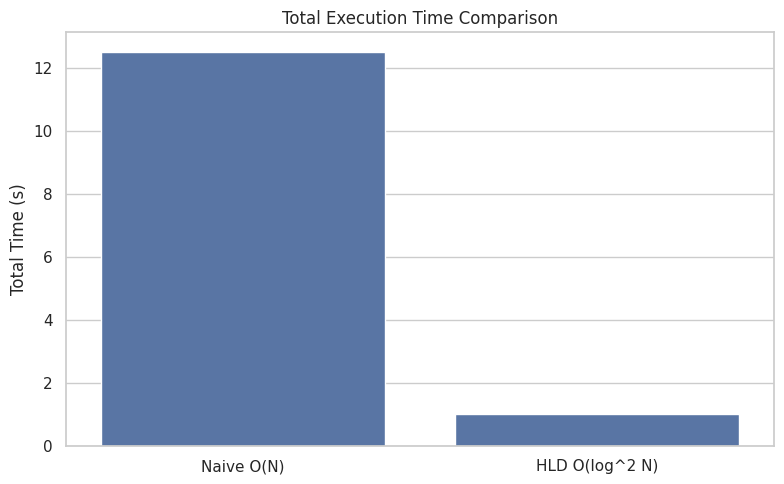

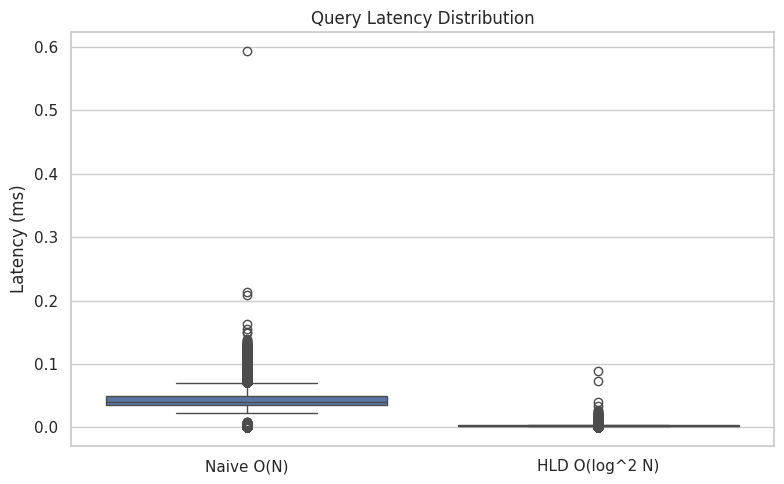

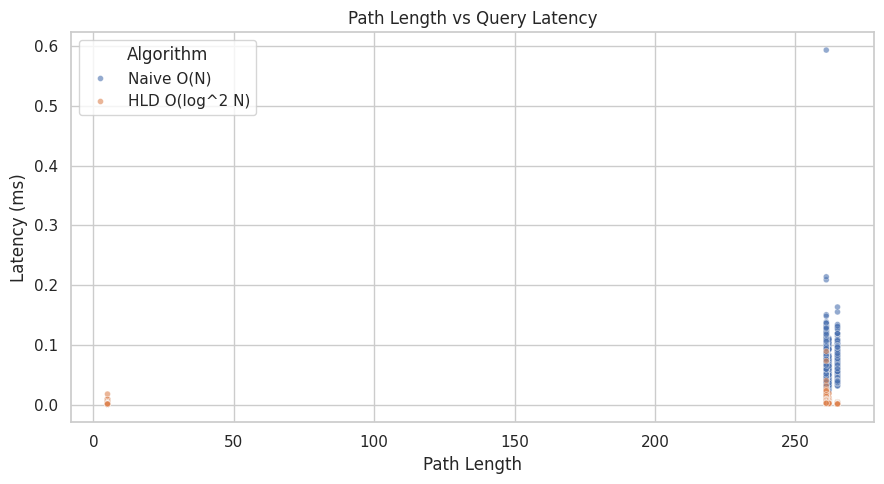

In [19]:
sns.set_theme(style="whitegrid")



plt.figure(figsize=(8, 5))

sns.barplot(data=summary, x="Algorithm", y="Total Time (s)")

plt.title("Total Execution Time Comparison")

plt.ylabel("Total Time (s)")

plt.xlabel("")

plt.tight_layout()

plt.show()



latency_df = pd.DataFrame(

    {

        "Algorithm": ["Naive O(N)"] * len(naive_latencies) + ["HLD O(log^2 N)"] * len(hld_latencies),

        "Latency (ms)": naive_latencies + hld_latencies,

    }

)



plt.figure(figsize=(8, 5))

sns.boxplot(data=latency_df, x="Algorithm", y="Latency (ms)")

plt.title("Query Latency Distribution")

plt.xlabel("")

plt.tight_layout()

plt.show()



scatter_df = pd.DataFrame(

    {

        "Path Length": path_lengths + path_lengths,

        "Latency (ms)": naive_latencies + hld_latencies,

        "Algorithm": ["Naive O(N)"] * len(path_lengths) + ["HLD O(log^2 N)"] * len(path_lengths),

    }

)



plt.figure(figsize=(9, 5))

sns.scatterplot(data=scatter_df, x="Path Length", y="Latency (ms)", hue="Algorithm", alpha=0.6, s=18)

plt.title("Path Length vs Query Latency")

plt.tight_layout()

plt.show()
